<a href="https://colab.research.google.com/github/faisu6339-glitch/Machine-learning/blob/main/Decision_Tree(Part_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 56.4 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


2026-02-18 18:25:48.319 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 18:25:49.083 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-02-18 18:25:49.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 18:25:49.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 18:25:49.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 18:25:49.096 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 18:25:49.100 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 18:25:49.106 Thread 'MainThread': mi

DeltaGenerator()

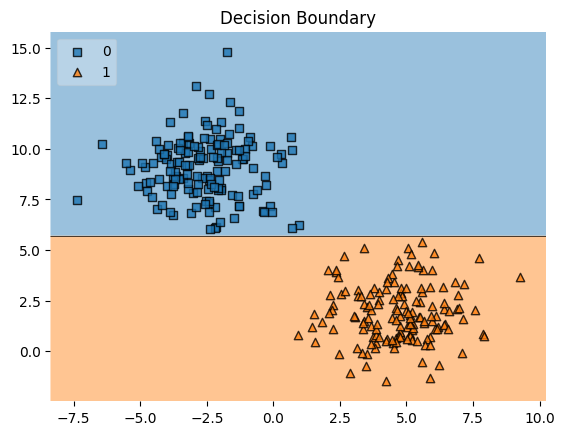

In [2]:
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier
from mlxtend.plotting import plot_decision_regions

# Title
st.title("Decision Tree Classifier Visualizer")

# Sidebar Controls
st.sidebar.header("Model Parameters")

criterion = st.sidebar.selectbox(
    "Criterion",
    ("gini", "entropy", "log_loss")
)

splitter = st.sidebar.selectbox(
    "Splitter",
    ("best", "random")
)

max_depth = st.sidebar.slider(
    "Max Depth",
    min_value=1,
    max_value=20,
    value=3
)

min_samples_split = st.sidebar.slider(
    "Min Samples Split",
    min_value=2,
    max_value=20,
    value=2
)

min_samples_leaf = st.sidebar.slider(
    "Min Samples Leaf",
    min_value=1,
    max_value=20,
    value=1
)

max_features = st.sidebar.slider(
    "Max Features",
    min_value=1,
    max_value=2,
    value=2
)

# Generate dataset
X, y = make_blobs(
    n_samples=300,
    centers=2,
    random_state=42,
    cluster_std=1.5
)

# Model
model = DecisionTreeClassifier(
    criterion=criterion,
    splitter=splitter,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    max_features=max_features,
    random_state=42
)

model.fit(X, y)

# Plot decision boundary
fig, ax = plt.subplots()
plot_decision_regions(X, y, clf=model, legend=2)
plt.title("Decision Boundary")
st.pyplot(fig)


#Decisio Tree on iris dataset

In [3]:
# Classification Example
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Prediction
y_pred = clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


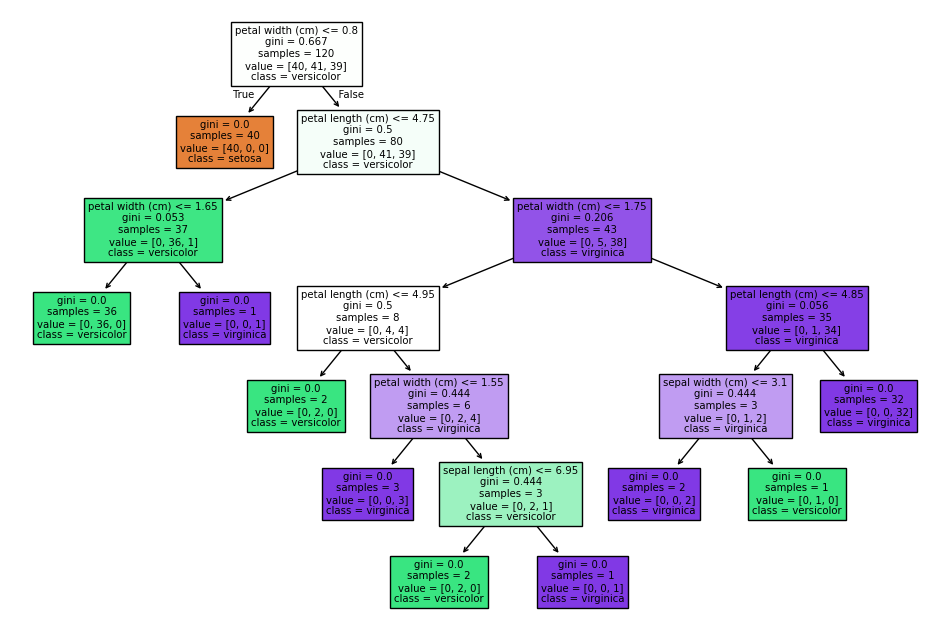

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()


In [5]:
clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    criterion='entropy'
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [6]:
# Regression Example
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Load data
data = fetch_california_housing()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
reg = DecisionTreeRegressor(max_depth=5)
reg.fit(X_train, y_train)

# Prediction
y_pred = reg.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))


MSE: 0.5245146178314736


In [7]:
# Gini
clf_gini = DecisionTreeClassifier(criterion='gini')
clf_gini.fit(X_train, y_train)

# Entropy
clf_entropy = DecisionTreeClassifier(criterion='entropy')
clf_entropy.fit(X_train, y_train)

print("Gini Accuracy:", accuracy_score(y_test, clf_gini.predict(X_test)))
print("Entropy Accuracy:", accuracy_score(y_test, clf_entropy.predict(X_test)))


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [8]:
from sklearn.model_selection import cross_val_score

clf = DecisionTreeClassifier(max_depth=4)
scores = cross_val_score(clf, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/tree/_classes.py", line 1024, in fit
    super()._fit(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/tree/_classes.py", line 294, in _fit
    check_classification_targets(y)
  File "/usr/local/lib/python3.12/dist-packages/sklear